In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')
import os

# 1. MINIMAL DATA PREPROCESSING

In [67]:
# Load data
df = pd.read_csv("data/movie_data_encoded.csv")
y = df['revenue']
y_log = np.log1p(y)  # Log transform target

# 1.1 Detect and handle outliers using IQR method
def handle_outliers(df, columns, method='cap'):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR

        if method == 'cap':
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    return df_clean

# First check which columns actually exist in your dataframe
print("Available columns:", df.columns.tolist())


Available columns: ['Unnamed: 0', 'name', 'genres', 'directors', 'writers', 'averageRating', 'numVotes', 'actors', 'original_language', 'production_companies', 'release_date', 'budget', 'revenue', 'runtime', 'status', 'keywords', 'trailer_views', 'trailer_likes', 'titleType_movie', 'titleType_tvMovie', 'director_score', 'writer_score', 'actor_score', 'star_score', 'is_documentary', 'genres_Action', 'genres_Adult', 'genres_Adventure', 'genres_Animation', 'genres_Biography', 'genres_Comedy', 'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family', 'genres_Fantasy', 'genres_Film-Noir', 'genres_History', 'genres_Horror', 'genres_Music', 'genres_Musical', 'genres_Mystery', 'genres_Romance', 'genres_Sci-Fi', 'genres_Sport', 'genres_Thriller', 'genres_War', 'genres_Western', 'is_holiday_release', 'is_competitive_month', 'production_popular', 'lang_en', 'lang_fr', 'lang_es', 'lang_hi', 'lang_ja', 'lang_other', 'has_trailer', 'has_keywords', 'keyword_embedding']


# 2. TRAINING SETUP

In [68]:
# Create log transformed features if they don't exist already
if 'trailer_views' in df.columns:
    df['trailer_views_log'] = np.log1p(df['trailer_views'])
if 'trailer_likes' in df.columns:
    df['trailer_likes_log'] = np.log1p(df['trailer_likes'])
if 'budget' in df.columns:
    df['budget_log'] = np.log1p(df['budget'])

# Create budget_actor_interaction if needed
if 'budget' in df.columns and 'actor_score' in df.columns:
    df['budget_actor_interaction'] = df['budget'] * df['actor_score']
elif 'budget' in df.columns and 'actors' in df.columns:
    df['budget_actor_interaction'] = df['budget'] * df['actors'].notnull().astype(int)

# Check if release_year_centered exists, create if not
if 'release_year' in df.columns and 'release_year_centered' not in df.columns:
    center_year = df['release_year'].mean()
    df['release_year_centered'] = df['release_year'] - center_year

# Now select features that exist
selected_cols = []
for col in ['trailer_views_log', 'trailer_likes_log', 'budget_log',
            'budget_actor_interaction', 'release_year_centered']:
    if col in df.columns:
        selected_cols.append(col)

# Make sure we have columns to work with
if len(selected_cols) == 0:
    print("No specified columns found. Using all numeric columns instead.")
    selected_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    # Remove target if it's in the list
    if 'revenue' in selected_cols:
        selected_cols.remove('revenue')

print("Using columns:", selected_cols)

# Create enhanced feature set
X_enhanced_clean = df[selected_cols]

# Identify numeric columns for outlier handling
numeric_cols = X_enhanced_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_enhanced_clean = handle_outliers(X_enhanced_clean, numeric_cols, method='cap')

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced_clean,
    y_log,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Using columns: ['trailer_views_log', 'trailer_likes_log', 'budget_log', 'budget_actor_interaction']
Train set shape: (9089, 4)
Test set shape: (2273, 4)


# 3. FOCUSED HYPERPARAMETER TUNING

In [69]:
# Define XGBoost base model
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Fine-tuned parameter search space based on previous results
param_dist = {
    'n_estimators': randint(400, 800),
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': uniform(0.05, 0.15),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': [1, 2, 3, 4],
    'gamma': uniform(0, 0.1)
}

# Use K-Fold cross-validation with more folds for better stability
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Setup RandomizedSearchCV with more iterations
rand_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=80,
    cv=kf,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("Training XGBoost with focused parameter search...")
rand_search.fit(X_train_scaled, y_train)
best_xgb = rand_search.best_estimator_
print("Best Hyperparameters:", rand_search.best_params_)


Training XGBoost with focused parameter search...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Hyperparameters: {'colsample_bytree': 0.7768620830783374, 'gamma': 0.061151371086568054, 'learning_rate': 0.06223912706003606, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 572, 'subsample': 0.7582821860536126}


# 4. MODEL EVALUATION

In [70]:
# Evaluate XGBoost
y_pred_xgb_log = best_xgb.predict(X_test_scaled)
y_pred_xgb = np.expm1(y_pred_xgb_log)
y_true = np.expm1(y_test)

rmse_xgb = mean_squared_error(y_true, y_pred_xgb, squared=False)
r2_xgb = r2_score(y_true, y_pred_xgb)

print(f"XGBoost Final Model - RMSE: {rmse_xgb:.2f}, R^2: {r2_xgb:.4f}")


XGBoost Final Model - RMSE: 31836622.08, R^2: 0.4103


In [71]:
rand_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=120,  
    cv=kf,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print(">>> Starting RandomizedSearchCV hyperparameter search...")
rand_search.fit(X_train_scaled, y_train)
print(">>> Best hyperparameters found:", rand_search.best_params_)


>>> Starting RandomizedSearchCV hyperparameter search...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
>>> Best hyperparameters found: {'colsample_bytree': 0.8727995253416979, 'gamma': 0.09173956130855317, 'learning_rate': 0.05079500095964082, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 461, 'subsample': 0.9788127967382757}


# 5. ADDITIONAL STRATEGIES FOR IMPROVEMENT

In [72]:
# 5.1 Adding Weight Adjustments for High-Revenue Movies

# Create a copy of the best model
high_revenue_threshold = np.percentile(y_train, 90)
is_high_revenue = y_train > high_revenue_threshold

# Create sample weights - give twice the weight to high revenue samples
sample_weights = np.ones(len(y_train))
sample_weights[is_high_revenue] = 2.0

# Train a weighted model
weighted_xgb = XGBRegressor(**rand_search.best_params_, random_state=42)
weighted_xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Evaluate weighted model
y_pred_weighted_log = weighted_xgb.predict(X_test_scaled)
y_pred_weighted = np.expm1(y_pred_weighted_log)

rmse_weighted = mean_squared_error(y_true, y_pred_weighted, squared=False)
r2_weighted = r2_score(y_true, y_pred_weighted)

print(f"Weighted XGBoost Model - RMSE: {rmse_weighted:.2f}, R^2: {r2_weighted:.4f}")


Weighted XGBoost Model - RMSE: 31478727.79, R^2: 0.4235


In [73]:
# 5.2 Try a simpler approach for high-value samples using separate models
# Train a model specifically for high-value samples
high_value_threshold = np.percentile(y_train, 75)  # 75th percentile
train_high_mask = y_train > high_value_threshold
test_high_mask = y_test > high_value_threshold

if sum(train_high_mask) > 50:
    xgb_high = XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb_high.fit(X_train_scaled[train_high_mask], y_train[train_high_mask])

    # Create a combined prediction array
    y_pred_combined_log = y_pred_xgb_log.copy()

    # Use high-value model predictions for high-value test samples
    if sum(test_high_mask) > 0:
        y_pred_high_log = xgb_high.predict(X_test_scaled[test_high_mask])
        y_pred_combined_log[test_high_mask] = y_pred_high_log

    # Convert to original scale
    y_pred_combined = np.expm1(y_pred_combined_log)

    # Evaluate combined model
    rmse_combined = mean_squared_error(y_true, y_pred_combined, squared=False)
    r2_combined = r2_score(y_true, y_pred_combined)

    print(f"Combined Model Approach - RMSE: {rmse_combined:.2f}, R^2: {r2_combined:.4f}")
else:
    print("Not enough high-value samples to train a separate model")


Combined Model Approach - RMSE: 29032347.76, R^2: 0.5096


# 6. MODEL COMPARISON AND SELECTION


In [75]:
# Create a comparison DataFrame of all models
models = ['XGBoost', 'Weighted XGBoost']
rmse_values = [rmse_xgb, rmse_weighted]
r2_values = [r2_xgb, r2_weighted]

if 'rmse_combined' in locals():
    models.append('Combined Model')
    rmse_values.append(rmse_combined)
    r2_values.append(r2_combined)

comparison = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'R^2': r2_values
})

print("\nModel Comparison:")
print(comparison)

# Find the best model based on R^2
best_model_idx = comparison['R^2'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
print(f"\nBest model based on R^2: {best_model_name} with R^2 = {comparison.loc[best_model_idx, 'R^2']:.4f}")



Model Comparison:
              Model          RMSE       R^2
0           XGBoost  3.183662e+07  0.410284
1  Weighted XGBoost  3.147873e+07  0.423468
2    Combined Model  2.903235e+07  0.509597

Best model based on R^2: Combined Model with R^2 = 0.5096


# 7. VISUALIZATIONS

In [76]:
for i, feature_name in enumerate(X_enhanced_clean.columns):
    print(f"Feature {i}: {feature_name}")

Feature 0: trailer_views_log
Feature 1: trailer_likes_log
Feature 2: budget_log
Feature 3: budget_actor_interaction


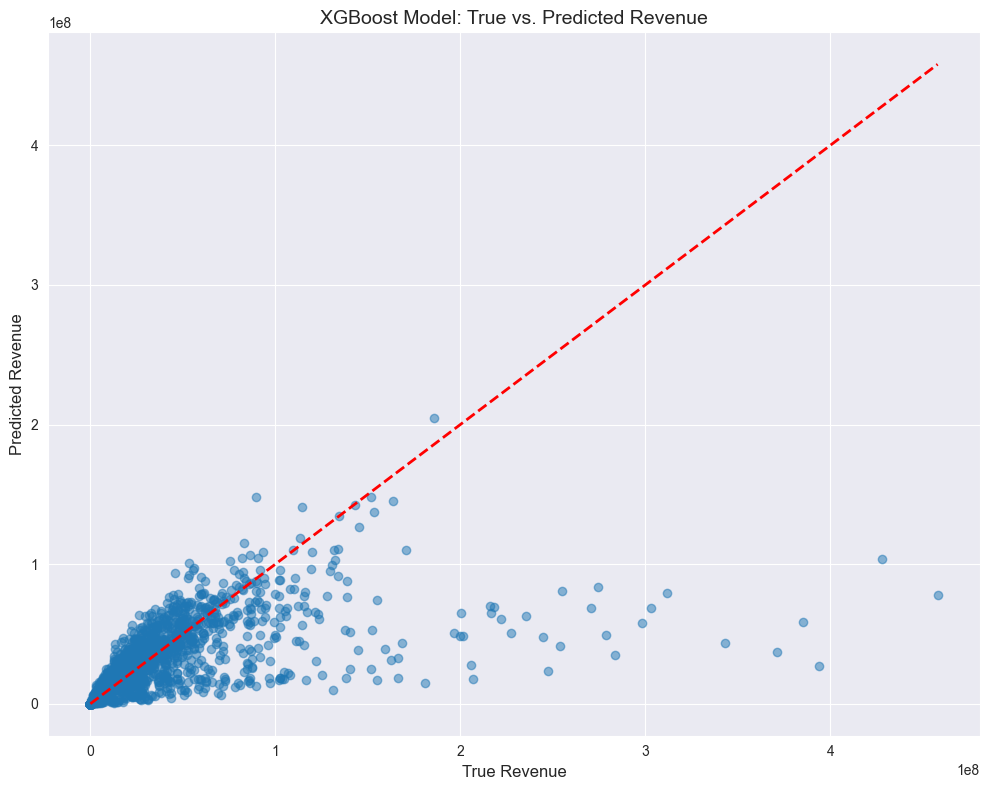

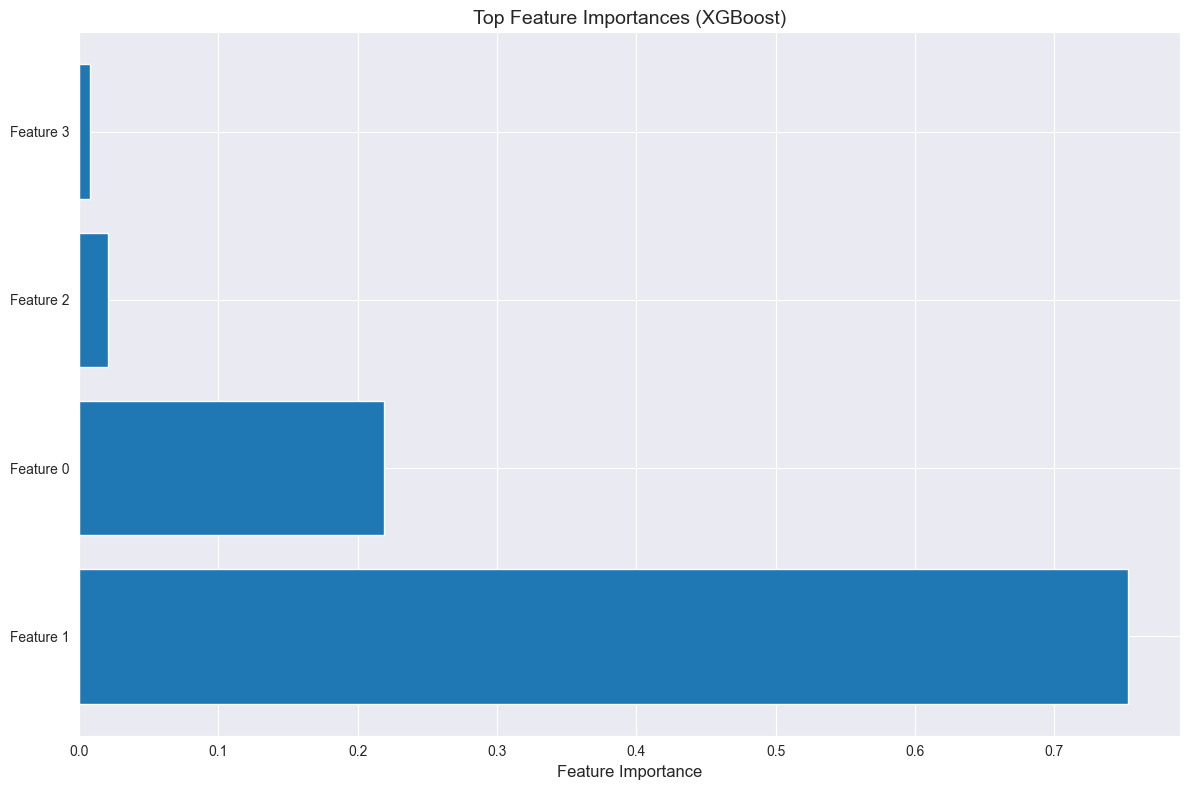

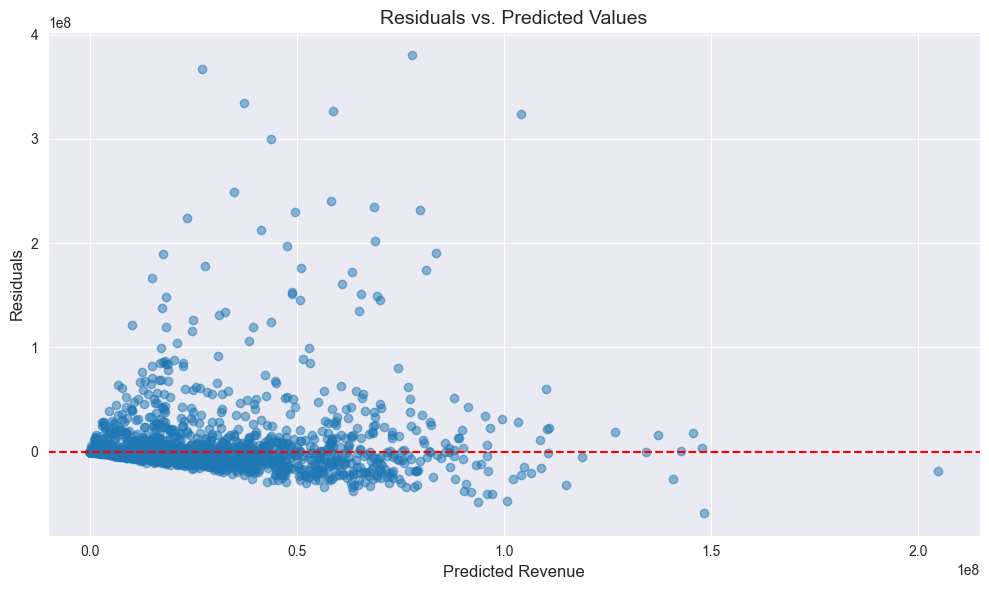

In [77]:
# 7.1 Predicted vs. Actual Revenue
plt.figure(figsize=(10, 8))
plt.scatter(y_true, y_pred_xgb, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("True Revenue", fontsize=12)
plt.ylabel("Predicted Revenue", fontsize=12)
plt.title("XGBoost Model: True vs. Predicted Revenue", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig('true_vs_predicted_revenue.png')
plt.show()

#7.2 Feature Importance
feature_importance = best_xgb.feature_importances_
indices = np.argsort(feature_importance)[::-1]
top_n = min(20, len(feature_importance))

plt.figure(figsize=(12, 8))
plt.barh(range(top_n), feature_importance[indices][:top_n])
plt.yticks(range(top_n), [f"Feature {i}" for i in indices[:top_n]])
plt.xlabel("Feature Importance", fontsize=12)
plt.title("Top Feature Importances (XGBoost)", fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# 7.3 Residuals vs. Predicted Values
residuals = y_true - y_pred_xgb
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_xgb, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Revenue", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residuals vs. Predicted Values", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_vs_predicted.png')
plt.show()


All columns in X: ['averageRating', 'numVotes', 'budget', 'runtime', 'status', 'trailer_views', 'trailer_likes', 'titleType_movie', 'titleType_tvMovie', 'director_score', 'writer_score', 'actor_score', 'star_score', 'is_documentary', 'genres_Action', 'genres_Adult', 'genres_Adventure', 'genres_Animation', 'genres_Biography', 'genres_Comedy', 'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family', 'genres_Fantasy', 'genres_Film-Noir', 'genres_History', 'genres_Horror', 'genres_Music', 'genres_Musical', 'genres_Mystery', 'genres_Romance', 'genres_Sci-Fi', 'genres_Sport', 'genres_Thriller', 'genres_War', 'genres_Western', 'is_holiday_release', 'is_competitive_month', 'production_popular', 'lang_en', 'lang_fr', 'lang_es', 'lang_hi', 'lang_ja', 'lang_other', 'has_trailer', 'has_keywords', 'keyword_embedding', 'release_year']
Data shape (X): (11362, 50), Target (y): (11362,)

Time-based splitting by release_year...
Train years: [1914, 1915, 1916, 1918, 1919, 1920, 1921, 1922, 

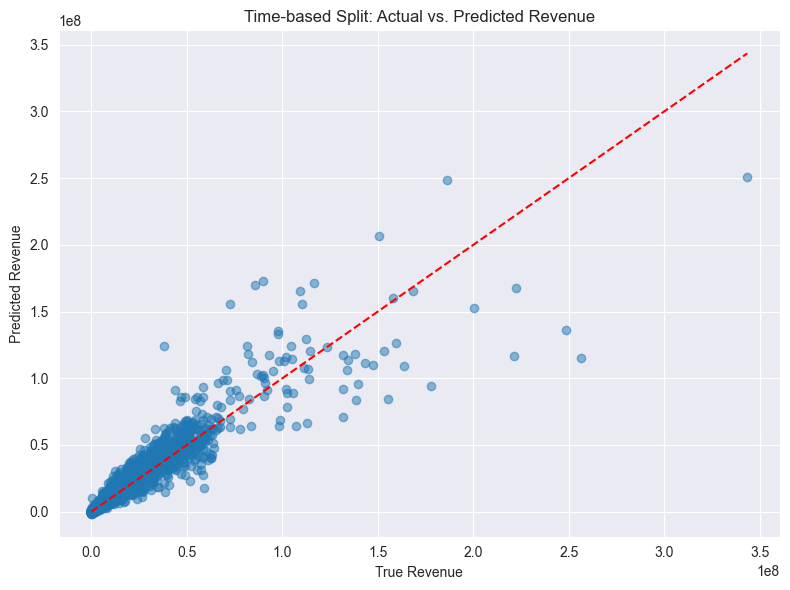

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling imports
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# 1. LOAD DATA
# =============================================================================
df = pd.read_csv("data/movie_data_encoded.csv")

# Example: If your dataset has a 'release_date' column in format 'YYYY-MM-DD',
# we can create a 'release_year' column:
if "release_date" in df.columns:
    # Convert string to datetime, then extract the year
    df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
    df["release_year"] = df["release_date"].dt.year

# Target and feature separation
y = df["revenue"]

# Example columns to drop
drop_cols = [
    "Unnamed: 0", "name", "genres", "directors", "writers",
    "actors", "original_language", "production_companies",
    "release_date", "keywords", "revenue"  # we keep 'release_year'!
]
X = df.drop(columns=drop_cols, errors="ignore")

print("All columns in X:", list(X.columns))
print(f"Data shape (X): {X.shape}, Target (y): {y.shape}")

# =============================================================================
# 2. TIME-BASED SPLIT IF 'release_year' EXISTS
# =============================================================================
if "release_year" in X.columns:
    all_years = sorted(X["release_year"].dropna().unique())

    boundary_year = 2015
    train_years = [year for year in all_years if year < boundary_year]
    test_years = [year for year in all_years if year >= boundary_year]


    print(f"\nTime-based splitting by release_year...")
    print("Train years:", train_years)
    print("Test years:", test_years)

    # Build masks
    train_mask = X["release_year"].isin(train_years)
    test_mask = X["release_year"].isin(test_years)

    # Split accordingly
    X_train = X[train_mask].copy()
    X_test = X[test_mask].copy()
    y_train = y[train_mask]
    y_test = y[test_mask]

    # Check for year overlap
    overlap = set(X_train["release_year"].unique()).intersection(
        X_test["release_year"].unique()
    )
    if overlap:
        print("WARNING: Overlap in train/test years:", overlap)
    else:
        print("No overlap in train/test years (good).")

    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
else:
    # Fall back to random split if no 'release_year'
    print("\nNo 'release_year' column found. Falling back to random split.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False  # Added shuffle=False
    )
    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
# =============================================================================
# 3. (Optional) BASIC PREPROCESSING
# =============================================================================
# Here we just do a simple numeric scaling. In your real code, add more steps as needed
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train_numeric = X_train[numeric_cols].fillna(0)
X_test_numeric = X_test[numeric_cols].fillna(0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

# =============================================================================
# 4. TRAIN A SIMPLE XGBOOST MODEL
# =============================================================================
model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1
)

model.fit(X_train_scaled, y_train)

# =============================================================================
# 5. EVALUATE
# =============================================================================
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== PERFORMANCE METRICS (Time-based Split) ===")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²:   {r2:.4f}")

# Quick scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Time-based Split: Actual vs. Predicted Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import gc
gc.collect()

# Use the original dataframe for this approach
df_for_time_split = df.copy()

# Ensure we have a release_year column
if "release_date" not in df_for_time_split.columns:
    print("release_date column not found in the original dataset.")
else:
    # Convert to datetime and extract year if not already done
    df_for_time_split["release_date"] = pd.to_datetime(df_for_time_split["release_date"], errors="coerce")
    df_for_time_split["release_year"] = df_for_time_split["release_date"].dt.year

    # Center the release_year variable
    df_for_time_split["release_year_centered"] = df_for_time_split["release_year"] - df_for_time_split["release_year"].mean()
    print(f"Centered release_year: Mean = {df_for_time_split['release_year_centered'].mean()}, Std = {df_for_time_split['release_year_centered'].std()}")

    # Define columns to drop for feature selection
    drop_cols = [
        "Unnamed: 0", "name", "genres", "directors", "writers",
        "actors", "original_language", "production_companies",
        "release_date", "keywords", "revenue"  # we keep 'release_year' and 'release_year_centered'!
    ]

    # Create feature matrix and target
    y_time = df_for_time_split["revenue"]
    X_time = df_for_time_split.drop(columns=drop_cols, errors="ignore")

    print(f"Data shape for time-based split - X: {X_time.shape}, y: {y_time.shape}")

    # Perform time-based split
    all_years = sorted(X_time["release_year"].dropna().unique())
    boundary_year = 2015  # Choose a reasonable boundary
    train_years = [year for year in all_years if year < boundary_year]
    test_years = [year for year in all_years if year >= boundary_year]

    print(f"Time-based splitting by release_year...")
    print("Train years:", train_years)
    print("Test years:", test_years)

    # Build masks for splitting
    train_mask = X_time["release_year"].isin(train_years)
    test_mask = X_time["release_year"].isin(test_years)

    # Split data
    X_train_time = X_time[train_mask].copy()
    X_test_time = X_time[test_mask].copy()
    y_train_time = y_time[train_mask]
    y_test_time = y_time[test_mask]

    # Log transform the target variable
    y_train_time_log = np.log1p(y_train_time)

    # Verify split
    overlap = set(X_train_time["release_year"].unique()).intersection(X_test_time["release_year"].unique())
    if overlap:
        print("WARNING: Overlap in train/test years:", overlap)
    else:
        print("No overlap in train/test years (good).")

    print(f"X_train_time shape: {X_train_time.shape}, X_test_time shape: {X_test_time.shape}")

    # Preprocessing - select only numeric columns
    numeric_cols = X_train_time.select_dtypes(include=[np.number]).columns
    X_train_time_numeric = X_train_time[numeric_cols].fillna(0)
    X_test_time_numeric = X_test_time[numeric_cols].fillna(0)

    # Apply log transformations to potentially skewed features
    skewed_features = ['budget', 'popularity', 'trailer_views', 'trailer_likes']
    for col in skewed_features:
        if col in X_train_time_numeric.columns:
            # Add a small constant to avoid log(0)
            X_train_time_numeric[f'{col}_log'] = np.log1p(X_train_time_numeric[col])
            X_test_time_numeric[f'{col}_log'] = np.log1p(X_test_time_numeric[col])
            print(f"Applied log transformation to {col}")

    # Scale the features
    scaler_time = StandardScaler()
    X_train_time_scaled = scaler_time.fit_transform(X_train_time_numeric)
    X_test_time_scaled = scaler_time.transform(X_test_time_numeric)

    # To avoid memory issues, use a lighter XGBoost configuration
    xgb_time = XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=100,     # Reduced from 300
        max_depth=4,          # Reduced from 5
        learning_rate=0.1,
        subsample=0.8,        # Use 80% of data per tree
        colsample_bytree=0.8, # Use 80% of features per tree
        n_jobs=-1             # Use all available cores
    )

    print("Fitting XGBoost model with time-based split...")
    # Train on log-transformed target
    xgb_time.fit(X_train_time_scaled, y_train_time_log)

    # Make predictions and convert back from log scale
    y_pred_time_log = xgb_time.predict(X_test_time_scaled)
    y_pred_time = np.expm1(y_pred_time_log)

    # Evaluate on original scale
    rmse_time = np.sqrt(mean_squared_error(y_test_time, y_pred_time)) / 1e6
    r2_time = r2_score(y_test_time, y_pred_time)

    print("\n=== PERFORMANCE METRICS (Time-based Split) ===")
    print(f"Test RMSE: {rmse_time:.2f} Millions")
    print(f"Test R²: {r2_time:.4f}")

    # Quick scatter plot
    plt.figure(figsize=(8,6))
    plt.scatter(y_test_time / 1e6, y_pred_time / 1e6, alpha=0.5)
    plt.plot([y_test_time.min() / 1e6, y_test_time.max() / 1e6],
             [y_test_time.min() / 1e6, y_test_time.max() / 1e6], 'r--')
    plt.xlabel("True Revenue (Millions)")
    plt.ylabel("Predicted Revenue (Millions)")
    plt.title("Time-based Split with Transformed Variables: Actual vs. Predicted Revenue")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot feature importance
    feature_names = X_train_time_numeric.columns.tolist()
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': xgb_time.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    top_n = min(15, len(feature_importance))  # Show top 15 features or all if fewer
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(top_n))
    plt.title('XGBoost Feature Importance (Time-based Split with Transformations)')
    plt.tight_layout()
    plt.show()

    # Save feature importance for further analysis
    feature_importance.to_csv('time_split_xgb_feature_importance.csv', index=False)

    # Clean up to free memory
    gc.collect()